<h1 align = "center" style = "color : white;
    border : 2px solid black ;
    padding : 30px 0 30px 0;
    background: linear-gradient(135deg, #74ebd5, #ACB6E5);
    ">Partie 2
Manipulez les fonctions de base d'un modèle prédictif</h1>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression # Importation de la libraire pour la prediction de la variaable poid (contenant des dvaleur continues)
from sklearn.metrics import mean_squared_error, mean_absolute_error, mean_absolute_percentage_error # import des metrics
from sklearn.model_selection import train_test_split
# from sklearn.metrics import root_mean_squared_error

<style = "color : blue">Comprendre  le rôle central du jeu de données</h2>

<h1 style = "color : blue"
    >A- Évaluez la performance d’un modèle prédictif</h1>

Commençons ce chapitre par un petit exercice de mise en pratique, dans lequel on va :
- Charger un dataset.
- Entraîner le modèle.
- Évaluer le modèle.

Pour cela, nous allons partir d’un exemple simple de régression linéaire (nous verrons d’ailleurs cette notion plus en détail dans le chapitre suivant

Pour débuter, nous allons utiliser tous les échantillons du dataset sans le scinder en 2 (entraînement + test).

À noter que :

- l'âge est en mois et non en années (de 139 mois à 250 mois = de 11,5 à 20 ans) ;

- la variable sexe est binaire (  0  pour les garçons et  1  pour les filles) ;

- la taille en cm varie de 128,27 cm à 182,88 cm ;

- et la variable cible (c’est-à-dire le poids) est comprise entre 22,9 kg et 77,78 kg.


Nous allons construire un modèle qui prédit la variable cible (le poids de l'enfant) à partir des autres variables (sexe, âge et taille).

On cherche donc les coefficients  a  ,  b  ,  c  tels que :

poids = a * sexe + b * age + c * taille + du bruit

Rappel : le bruit représente l'information qui n'est pas capturée par le modèle linéaire.


In [70]:
# <a href = "https://github.com/OpenClassrooms-Student-Center/8063076-Initiez-vous-au-Machine-Learning/blob/master/data/age_vs_poids_vs_taille_vs_sexe.csv" 
#    style ="
#     font-weight : bold;
#     font-size : 17 px;
#     color : white;
#     background : red;
#     border : 2px solid black;
#     padding : 5px 5px 5px 5px;
#     border-radius : 20px"
#     >Dataset</a>

Cet dataset est charger et telecharger depuis un depot github

In [2]:
df = pd.read_csv("Dataset/age_vs_poids_vs_taille_vs_sexe.csv") # Chargement du  dataset
df.head()

,sexe,age,taille,poids
0,1,147,151.13,45.80
1,0,160,150.62,35.60
2,1,148,149.86,43.08
3,0,149,144.78,41.72
4,0,156,156.21,49.21


- **Petit analyse sur les donnees**

In [3]:
df.shape #237 = Echnantillons 

(237, 4)

In [4]:
df.info() # Donnes sans valeur manquantes

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 237 entries, 0 to 236
Data columns (total 4 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   sexe    237 non-null    int64  
 1   age     237 non-null    int64  
 2   taille  237 non-null    float64
 3   poids   237 non-null    float64
dtypes: float64(2), int64(2)
memory usage: 7.5 KB


<h3><span style = "color : red">Premier model</span>  :predire le poids en prenant le reste des variable dataset comment des variables predictive</h3>

- **Avec les competences acquise en suivant les tutos youtubes je vais moi meme coder et construre ce modele**

In [5]:
y_01 = df["poids"] #La variable cible
X_01 = df[["age", "taille", "sexe"]] #Les variables predictives

In [6]:
model = LinearRegression()
model.fit(X_01, y_01) #Entrainement du model
performance = model.score(X_01, y_01) 
print(f"Score de l'entrainment du model : {round(performance , 3)*100 } %")

Score de l'entrainment du model : 63.1 %


 La prediction du modele est R^2 = 0.631

In [7]:
# ainsi que les coefficients a,b,c de la régression linéaire
print(model.coef_, )

[0.10803477 0.55435737 0.15299379]


on a donc     **poids = 0.10 x age + 0.554 x taille 0.15 x sexe + bruit**      :D'apres ce que j'ai appris sur openclassroom

In [8]:
prediction_01 = model.predict(X_01) 

In [32]:
# print("Je viens de coder un model de regression lineaire mon premier exercice sur  openclassroom")
print("\n=================================================================================================")
print("Le modele conscite a entrer l'age , le sexe, et la taille et le modele nous retourne le poids")
print("=================================================================================================\n")

sexe = int(input("Entrer votre sexe : (1 pour Masculin et 0 Feminin) : "))
age = int(input("Entrer les mois de votre age :"))
taille = float(input("Entrer votre taille : "))
poids = model.predict(np.array([[sexe, taille, age]]))
print(f"Votre sexe : {sexe}\n- Votre taille : {taille}\n- Votre age : {age}\n -Prediction du poids : {round(float(poids), 2)} kg")


Le modele conscite a entrer l'age , le sexe, et la taille et le modele nous retourne le poids



Entrer votre sexe : (1 pour Masculin et 0 Feminin) :  1
Entrer les mois de votre age : 228
Entrer votre taille :  165


Votre sexe : 1
- Votre taille : 165.0
- Votre age : 228
 -Prediction du poids : 68.16 kg


C:\Users\dc\anacondau\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
C:\Users\dc\AppData\Local\Temp\ipykernel_5560\2784997934.py:10: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  print(f"Votre sexe : {sexe}\n- Votre taille : {taille}\n- Votre age : {age}\n -Prediction du poids : {round(float(poids), 2)} kg")


Pour ce modele entrainer sur les donnee qu'il connait  , j'ai essaye de predire mon poids et voila le resultat :

- Age : 19ans (228mois)
-  sexe Masculin (1)
- taille 165cm
- Mon poids d'apres **le model** serai : **68.16 kg**

<h3><span style = "color : red">Deuxieme modele</span> :trouver : predire le poids en prenant le sexe et l'age comment des variables predictives </h3>

In [33]:
model_02 = LinearRegression() #Initialisation du deuxieme modele

In [34]:
X_02 = df[["age", "sexe"]]
y_02 = df.poids

In [35]:
model_02.fit(X_02, y_02) # Entrainement du deuxieme model 
performance = round( model_02.score(X_02, y_02),3)
performance 

0.416

On a donc R^2 = 0.416

In [36]:
model_02.coef_ # les coeficient des vecteur 

array([ 0.30358882, -2.05854441])

on pour ce model **poids = 0.305 x age -2.05 x sexe + bruit**

In [37]:
prediction_02 = model_02.predict(X_02) # LES PREDICTIONS DU DEUXIEME MODEL SUR LES DONNEE DE L;ENMTRAINMENT

Donc rajouter la variable taille aux variables sexe et age permet de passer de R^2 = 0.41 a R^2 = 0.63, une nette amélioration !

#### Remarque : 

- <span style ="color : red" > 1. mean_squared_error (MSE)</span></br>
Mesure la moyenne des carrés des erreurs entre les valeurs réelles et les prédictions.
Plus le MSE est proche de 0, meilleures sont les prédiction</br>
on ecrit **mse = mean_squard_error(y_relle, ypredit)**</br></br>
- <span style ="color : red" >2. mean_absolute_error  (MAE) </span></br>Mesure la moyenne de la valeur absolue des erreurs.</br>
Exemple : si le MAE vaut 2.5, cela signifie que le modèle se trompe en moyenne d'environ 2,5 unités.
Plus le MAE est proche de 0, mieux c'est.</br></br>
- <span style ="color : red" >3. mean_absolute_percentage_error (MAPE)</span></br>
  Erreur moyenne absolut

***À retenir*** : **MSE** pénalise fortement les grosses erreurs, **MAE** est plus facile à interpréter, et **MAPE**  donne une idée de l'erreur en pourcentage.

### Comparaison des deux models 

In [38]:
def Affiche_les_mesure(model,X, y_relle):  # J'ai eu envie de coder la fonction dans l'optic de me simplifier la tache au lieu de repeter les meme chose 
    mse = mean_squared_error(y_relle, model.predict(X))
    mae = mean_absolute_error(y_relle,model.predict(X))
    mape = mean_absolute_percentage_error(y_relle, model.predict(X))
    
    print(f"- La moyenne des carree des Erreur (MSE) :{round(mse,2)}")
    print(f"- La  moyenne de la valeur absolut des erreurs: {round(mae,2)}")
    print(f"- Erreur moyenne relative (%) :{round(mape, 2)*100} %")

## Premier modele (1) :

In [39]:
Affiche_les_mesure(model,X_01, y_01)

- La moyenne des carree des Erreur (MSE) :28.6
- La  moyenne de la valeur absolut des erreurs: 4.16
- Erreur moyenne relative (%) :9.0 %


## Deuxieme modele (2) :

In [40]:
Affiche_les_mesure(model_02, X_02, y_02) 

- La moyenne des carree des Erreur (MSE) :45.17
- La  moyenne de la valeur absolut des erreurs: 5.22
- Erreur moyenne relative (%) :12.0 %


#### Conclusion

Le modèle 1 est clairement meilleur que le modèle 2, car il fait moins d'erreurs sur les trois critères.

- MSE : 28,6 < 45,17 → modèle 1
- MAE : 4,16 < 5,22 → modèle 1
- MAPE : 9 % < 12 % → modèle 1

On peut donc dire que le modèle 1 est plus performant pour faire les prédictions.

Le modèle 1 a notamment une erreur moyenne absolue de 4,16 unités, contre 5,22 unités pour le modèle 2, et une erreur moyenne relative de 9 %, contre 12 %.

In [41]:
# Fin de l'exercice

<h3 style ="color : blue >Appliquez la méthodologie du processus d’entraînement</h3>

Dans les 3 chapitres suivants, nous entrerons plus en détail dans les différences entre :

- Régression linéaire.

- Classification.

- Et clustering.

Mais avant d’en arriver là, il est utile de souligner la similarité du processus d'entraînement qu'ils ont en commun. En effet, dans ces 3 contextes, entraîner un modèle va consister à enchaîner ces étapes :

- Charger les données.

- Transformer / améliorer les données. 

- Scinder les données en train / test ou train / test / validation.

- Entraîner le modèle avec plusieurs configurations de paramètres (si le modèle s'y prête).

- Calculer le score de chaque version du modèle.

Par rapport à l'exercice d'introduction du début de ce chapitre, nous avons rajouté les étapes 2 et 3.

Puis recommencer pour essayer d'obtenir un meilleur score !
En résumé

- La fonction de coût mesure l'erreur entre les prédictions d'un modèle et les valeurs réelles. Entraîner un modèle consiste à minimiser cette fonction de coût.

- Il existe de nombreuses fonctions de coût, chacune ayant ses propres avantages et inconvénients. La plus courante pour la régression est l'erreur quadratique moyenne (MSE).

- La performance d'un modèle peut être évaluée en utilisant une variété de mesures, telles que la racine de l'erreur quadratique moyenne (RMSE) ou le coefficient de détermination (R^2). 

- Dans un contexte de régression, pour les métriques de types RMSE, plus le score est petit, meilleur est le modèle. Contrairement au coefficient R^2, où un score proche de 1 indique un meilleur modèle.

Dans le chapitre suivant nous allons approfondir le sujet de la régression linéaire dans le cadre d'un nouveau jeu de données.

<h3 style = "color : blue">Appliquez la méthodologie du processus d’entraînement</h3>

Dans les 3 chapitres suivants, nous entrerons plus en détail dans les différences entre :

- <span style = "color : blue">Régression linéaire</span>.

- <span style = "color : blue">Classification</span>

- <span style = "color : blue">Et clustering</span>.


Mais avant d’en arriver là, il est utile de souligner la similarité du processus d'entraînement qu'ils ont en commun. En effet, dans ces 3 contextes, entraîner un modèle va consister à enchaîner ces étapes :

- Charger les données.

- Transformer / améliorer les données. 

- Scinder les données en train / test ou train / test / validation.

- Entraîner le modèle avec plusieurs configurations de paramètres (si le modèle s'y prête).

- Calculer le score de chaque version du modèle.

Par rapport à l'exercice d'introduction du début de ce chapitre, nous avons rajouté les étapes 2 et 3.

Puis recommencer pour essayer d'obtenir un meilleur score !

<h4 style = "color : blue">En résumé</h4>

**1** La fonction de coût** mesure l'erreur entre les prédictions d'un modèle et les valeurs réelles. ***Entraîner un modèle consiste à minimiser cette fonction de coût***.</br>

**2**.  Il existe de nombreuses fonctions de coût, chacune ayant ses propres avantages et inconvénients. La plus courante pour **la régression** est **l'erreur quadratique moyenne (MSE)**.</br>

**3**.   La performance d'un modèle peut être évaluée en utilisant une variété de mesures, telles que **la racine de l'erreur quadratique moyenne (RMSE) ou le coefficient de détermination (R^2)**. </br>

**4**.   Dans un contexte de régression, pour les métriques de types **RMSE**, ***plus le score est petit, meilleur est le modèle**. Contrairement au **coefficient R^2**, ***où un score proche de 1 indique un meilleur modèle***.</br>


Dans le chapitre suivant nous allons approfondir le sujet de **la régression linéaire** dans le cadre d'un nouveau jeu de données.

<!-- <a href = " https://openclassrooms.com/fr/courses/8063076-initiez-vous-au-machine-learning/8297644-evaluez-la-performance-d-un-modele-predictif?utm_source=chatgpt.com" 
   style ="
    font-weight : bold;
    font-size : 17 px;
    color : white;
    background : green;
    border : 2px solid black;
    padding : 5px 5px 5px 5px;
    border-radius : 20px"
    >Voir le cours complet sur openclassrooms</a> -->

<h1 style = "color : blue">B - Découvrez le principe de la régression linéaire</h1>

Considérons un nouveau dataset intitulé advertising. Il est disponible dans le GitHub du cours.

C'est un dataset classique issu du livre référence An introduction to Statistical Learning. Il contient 200 échantillons sur le budget alloué aux publicités télévisées, à la radio et dans les journaux, ainsi que les ventes résultantes.

- **Variable cible** :  `ventes`  (  `sales`  dans la version originale).

- **Prédicteurs** : budgets de publicité :

   - pour la TV :  `tv` ;

   - pour la la radio :  `radio`  ;

   - pour la presse :  `journaux`  (  `newspaper`  dans la version originale).

La variable cible,  ventes  , est continue, donc nous sommes bien dans une logique de régression (et non de classification).

Nous allons essayer de prédire le volume de vente en fonction du budget publicitaire en TV, radio et journaux.

Chargeons et explorons le dataset.

In [57]:
data = pd.read_csv("Dataset/advertising.csv") # Charge,ent du Dataset
data.head()

,tv,radio,journaux,ventes
0,230.1,37.8,69.2,22.1
1,44.5,39.3,45.1,10.4
2,17.2,45.9,69.3,9.3
3,151.5,41.3,58.5,18.5
4,180.8,10.8,58.4,12.9


In [58]:
#Petit analyse 

In [59]:
data.isnull().sum()

tv          0
radio       0
journaux    0
ventes      0
dtype: int64

In [60]:
data.describe().round(2) # Les stats descriptives

,tv,radio,journaux,ventes
count,200.00,200.00,200.00,200.00
mean,147.04,23.26,30.55,14.02
std,85.85,14.85,21.78,5.22
min,0.70,0.00,0.30,1.60
25%,74.38,9.98,12.75,10.38
50%,149.75,22.90,25.75,12.90
75%,218.82,36.52,45.10,17.40
max,296.40,49.60,114.00,27.00


Avant d'entraîner le modèle, il convient de regarder les relations entre les différentes variables. Pour cela nous utilisons Seaborn et Matplotlib, librairies de visualisation en Python.

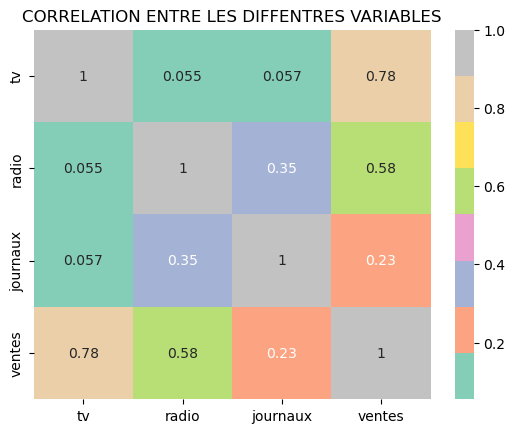

In [61]:
# Correlation enrtrew les variables
plt.title("CORRELATION ENTRE LES DIFFENTRES VARIABLES")
sns.heatmap(data.corr(numeric_only = True), annot= True, alpha = 0.8, cmap = "Set2")
plt.show()

In [62]:
X = data[["tv","radio","journaux"]]
y = data["ventes"]


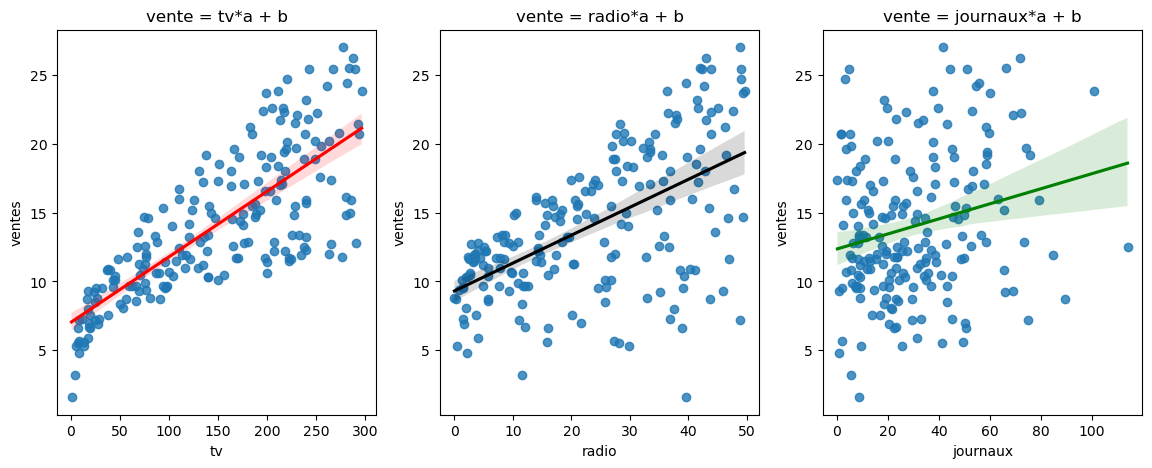

In [63]:
plt.figure(figsize = (14,5))
plt.subplot(1,3,1)
plt.title("vente = tv*a + b")
sns.regplot(x = X["tv"], y = y, line_kws={"color" : "red"})
plt.subplot(1,3,2)
plt.title("vente = radio*a + b")
sns.regplot(x = X["radio"], y = y, line_kws={"color" : "black"})
plt.subplot(1,3,3)
plt.title("vente = journaux*a + b")
sns.regplot(x = X["journaux"], y = y, line_kws={"color" : "green"})
plt.show()

Les zones rouges, noires, vertes  pâle reflète l'incertitude du modèle. **Plus elle est grande**, ***moins la régression est fiable***.

Le graphe montre que :

- tv  est plus prédictive des ventes que  radio  ;

- radio  est plus prédictive que  journaux  .

- L'observation est confirmée par les coefficients de corrélation 

In [64]:
modele_vente = LinearRegression() 

Cette fois-ci, on va scinder notre dataset en une partie d'entraînement et une partie d'évaluation en utilisant la fonction ***train_test_split*** de scikit-learn.

Cette fonction prends les variables d'entrée, la variable cible, un ratio et retourne 4 objets :

- X_train  : prédicteurs pour l'entraînement ;

- X_test  : prédicteurs pour l'évaluation ;

- y_train  : variable cible pour l'entraînement ;

- y_test  : variable pour l'évaluation.

On va ensuite utiliser :

- X_train  et  y_train  pour entraîner le modèle (train en anglais) ;

- X_test  et  y_test  pour l'évaluer (test en anglais).

Cela donne :

In [65]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42)

In [66]:
print(f"- Donne de l'entrainement :{X_train.shape}\n- Donnees de l'evaluation : {X_test.shape}")

- Donne de l'entrainement :(160, 3)
- Donnees de l'evaluation : (40, 3)


On a donc 160 échantillons pour entraîner notre modèle et 40 échantillons que le modèle ne voit pas pendant son entraînement et qui nous serviront à l'évaluer.

Le terme **random_state** est un paramètre qui permet de contrôler la reproductibilité des résultats lorsque vous effectuez des opérations qui impliquent de l'aléatoire, comme par exemple scinder les données en sous-ensembles de train et test.

En fixant une valeur spécifique pour random_state, vous vous assurez que les opérations aléatoires se déroulent toujours de la même manière. Les résultats sont reproductibles et vous pouvez comparer différents modèles.

On entraîne le modèle :

In [67]:
modele_vente.fit(X_train, y_train)

LinearRegression()

Pour estimer la performance sur le sous-ensemble de test, il faut tout d'abord obtenir les prédictions pour  X_test  :

In [68]:
# Les prediction du model 

y_pred_test = modele_vente.predict(X_test)

On peut maintenant calculer l'écart entre les vraies valeurs de test  (y_test)  et celles prédites par le modèle.

Utilisons la RMSE et la MAPE comme scores. Pour ces 2 métriques, un score plus petit correspond à un meilleur modèle. MAPE est comprise entre 0 et 1, tandis que RMSE n'est pas contrainte.

In [69]:
mse = mean_squared_error(y_test, y_pred_test)
mape = mean_absolute_percentage_error(y_test, y_pred_test)
print(f"\n\nLa racine carree de la moyenne des carrer des erreurs :{round(mse,2)}")
print(f"L'la moyenne de l;erreur absolue : {round(mape, 2) *100} %")



La racine carree de la moyenne des carrer des erreurs :3.17
L'la moyenne de l;erreur absolue : 15.0 %
